In [1]:
# ----------------------------
# 1) Setup
# ----------------------------
from dotenv import load_dotenv

load_dotenv()
import uuid
from typing import List, Annotated, TypedDict
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage
from langgraph.graph.message import add_messages, RemoveMessage # optimised reducer for message state
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langgraph.checkpoint.memory import InMemorySaver

import os

In [2]:
os.environ["LANGCHAIN_PROJECT"] = "chatbot_with_long_and_short_mem"


In [3]:
# ----------------------------
# 2) Long-term memory store (semantic index over embeddings)
# ----------------------------
embedding_model = OpenAIEmbeddings(model='text-embedding-3-small')
store = InMemoryStore(index={'embed': embedding_model, 'dims': 1536})

In [4]:
# ----------------------------
# 3) Graph state
# ----------------------------
class chatstate(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    summary: str

In [5]:
# ----------------------------
# 4) Structured-output schemas for the memory extractor
# ----------------------------
class MemoryItem(BaseModel):
    text: Annotated[str, Field(description="Atomic user memory")]
    is_new: Annotated[bool, Field(description="True if new, false if duplicate")]

class MemoryDecision(BaseModel):
    should_write: bool
    memories: Annotated[List[MemoryItem], Field(default_factory=list)]

In [6]:
# ----------------------------
# 5) LLMs
# ----------------------------
extractor_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(MemoryDecision)

summariser_llm = ChatOpenAI(model='gpt-4o-mini')
chat_llm = ChatOpenAI(model="gpt-4o-mini")


In [7]:
# ----------------------------
# 6) Prompt templates
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant. Use the known details about the user below to \
personalize your replies. Don't mention that you're using stored memories.

Known details about the user:
{user_details_content}

Summary of the conversation so far (older messages have been trimmed, rely on this for earlier context):
{summary_content}
"""

In [8]:
MEMORY_PROMPT_TEMPLATE = """You maintain long-term memory about the user for a conversational assistant.

Existing known details about the user:
{user_details_content}

Read the user's latest message and decide whether it contains new, durable facts worth remembering \
(e.g. name, role, preferences, goals). Only extract atomic facts that are not already present above. \
If nothing new and memorable is present, set should_write to False and return no memories.
"""

In [9]:
# ----------------------------
# 7) Nodes
# ----------------------------
def remember_node(state: chatstate, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    # existing memory
    items = store.search(namespace)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = extractor_llm.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT_TEMPLATE.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {}

In [10]:
def chat_node(state: chatstate, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    items = store.search(namespace, query=state["messages"][-1].content, limit=3)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)",
            summary_content=state.get("summary") or "(no summary yet)",
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

In [11]:
def should_summarize(state: chatstate):
    return len(state["messages"]) > 6

In [12]:
def summarise_conversation(state: chatstate, config: RunnableConfig):
    existing_summary = state.get("summary", "")

    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = summariser_llm.invoke(messages_for_summary)

    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

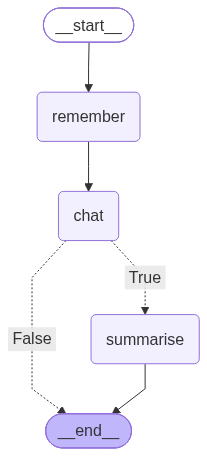

In [13]:
# ----------------------------
# 8) Graph
# ----------------------------
builder = StateGraph(chatstate)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)
builder.add_node("summarise", summarise_conversation)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarise",
        False: "__end__",
    }
)
builder.add_edge("summarise", END)

graph = builder.compile(checkpointer=InMemorySaver(),store=store)

graph

In [14]:
# ----------------------------
# 9) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1", "thread_id": "u1-session-1"}}

In [15]:
while True:
    query = input(f"Enter Your Query")

    if query.strip().lower() in ["quit","stop","exit"]:
        break
    else:
        result = graph.invoke({"messages": [{"role": "user", "content": query}]}, config)
        print("HUMAN:",query)
        print("AI:",result["messages"][-1].content)



HUMAN: Hi My name is Amitoj Singh Chawla

AI: Hi Amitoj! It's great to meet you. How can I assist you today?
HUMAN: I like to Eat Choclate cake, drink black coffe or a latte with a little drop of vanilla in it. i dont knwo what that coffee is called

AI: That's awesome! It sounds like you enjoy a classic vanilla latte, which is a great choice with the little drop of vanilla you like. Pairing it with chocolate cake must make for a delicious treat! Have you tried making your own vanilla latte at home?
HUMAN: i usually mix some sugar and cofee and beat it till frothy and pour milk into it with a small drop of vanilla extract at home daily. 

AI: That sounds like a perfect way to make your own vanilla latte! Beating the coffee and sugar to get it frothy must really enhance the flavor. It's nice to have that homemade touch every day. Do you enjoy baking as well, or do you usually buy your chocolate cake?
HUMAN: sometimes i bake else i buy it from the store. additioanlly i am building this c

In [16]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Amitoj Singh Chawla
Amitoj likes to eat chocolate cake.
Amitoj drinks black coffee or a latte with a little drop of vanilla in it.
Amitoj sometimes bakes chocolate cake or buys it from the store.
Amitoj is building a chatbot with long and short term memory in a Jupyter notebook and is testing it for potential deployment at scale.
Amitoj is currently focusing on memory for his chatbot project and plans to add tools later to create an agentic workflow.
Amitoj finds async programming difficult and is concerned about making his chatbot an MCP client along with other features.


In [20]:
snapshot = graph.get_state(config)

for m in snapshot.values["messages"]:
    print(f"{m.type}: {m.content}")

    print("\nSummary:", snapshot.values.get("summary") or "(none yet)")

human: sometimes i bake else i buy it from the store. additioanlly i am building this chatbot with long and short term memory in a jupyter notebook and am testing it to see if i could deploy it at scale


Summary: Amitoj Singh Chawla shared his preferences for chocolate cake and coffee, specifically a homemade vanilla latte made by mixing coffee and sugar until frothy, then adding milk and vanilla extract. He occasionally bakes but also buys chocolate cake from the store. Amitoj is currently developing a chatbot with long and short-term memory in a Jupyter notebook and is testing it for potential deployment at scale.
ai: That's exciting! Building a chatbot with long and short-term memory is a challenging but rewarding project. Jupyter notebooks are a great tool for development and testing. What specific features or functionalities are you focusing on for your chatbot? And are you integrating any particular frameworks or libraries?

Summary: Amitoj Singh Chawla shared his preferences fo